⟨n_m0⟩ = 0.012500747418329416    ⟨Z0Z1⟩ = 0.9950154676434434


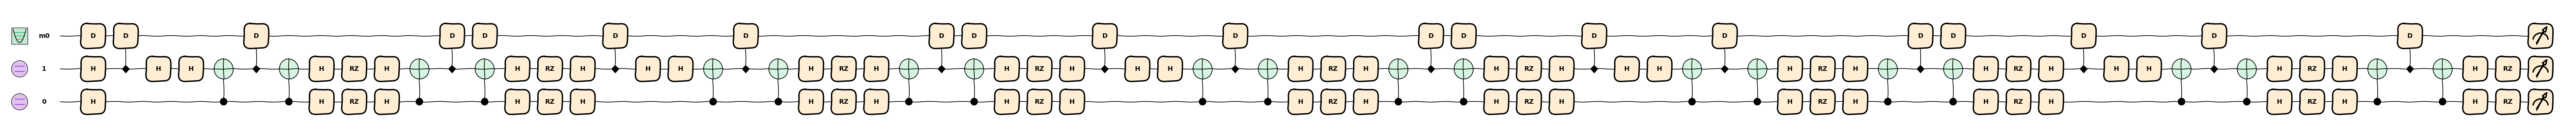

In [5]:
import numpy as np
import pennylane as qml
import hybridlane as hqml
from hybridlane.drawer.draw import draw_mpl

# ---- Device: one qumode "m0" + two qubits (implicit) ----
# Use a power-of-two Fock truncation (8, 16, ...)
dev = qml.device("bosonicqiskit.hybrid", shots=None, max_fock_level=8, hbar=2.0)

# ---- Problem constants (you can change these) ----
h = 1.0                   # grid spacing
alpha = 1.0               # thermal diffusivity scaling; absorbed into A if desired
# Coefficients λ_j in L = A = (1/h^2) * [ 2 I - (I ⊗ X) - 1/2 (XX + YY) ]
lam_I    =  2.0 / h**2
lam_X1   = -1.0 / h**2
lam_XX   = -0.5 / h**2
lam_YY   = -0.5 / h**2

def cond_disp(control_qubit, amp, mode="m0"):
    """Apply a conditional displacement D(amp) on `mode` controlled by Z on `control_qubit`.
       In HybridLane: ConditionalDisplacement takes (r, phi, wires=[qubit, mode]),
       where r * e^{i phi} = alpha in the standard D(alpha).
    """
    hqml.ConditionalDisplacement(amp, 0.0, wires=[control_qubit, mode])

def term_I(amp, mode="m0"):
    """Unconditional displacement by amp (implements e^{-i amp p})"""
    hqml.Displacement(amp, 0.0, wires=mode)

def term_X1(amp, mode="m0"):
    """e^{-i amp (X1 ⊗ p)} via H to Z-basis, conditional displacement on qubit 1"""
    qml.H(1)
    cond_disp(1, amp, mode)
    qml.H(1)

def term_XX(amp, mode="m0"):
    """e^{-i amp (X0 X1 ⊗ p)} via H on both -> ZZ, parity trick with a single control."""
    qml.H(0); qml.H(1)
    qml.CNOT(wires=[0,1])
    cond_disp(1, amp, mode)       # now it's Z1 ⊗ p
    qml.CNOT(wires=[0,1])
    qml.H(0); qml.H(1)

def term_YY(amp, mode="m0"):
    """e^{-i amp (Y0 Y1 ⊗ p)} via S;H on both -> ZZ, parity trick, then undo."""
    # Map Y -> Z using (S;H)
    qml.RZ(np.pi/2, wires=0); qml.RZ(np.pi/2, wires=1)  # S on both
    qml.H(0); qml.H(1)
    qml.CNOT(wires=[0,1])
    cond_disp(1, amp, mode)       # Z1 ⊗ p
    qml.CNOT(wires=[0,1])
    qml.H(0); qml.H(1)
    qml.RZ(-np.pi/2, wires=0); qml.RZ(-np.pi/2, wires=1)  # S^\dagger

def trotter_step(dt, mode="m0"):
    """One first-order Trotter step for e^{-i dt (L ⊗ p)} with L from Sec. 3.4.2."""
    # Amplitudes equal θ for D(θ) when hbar=2 (since e^{-iθ p} = D(θ))
    term_I(lam_I * dt, mode)
    term_X1(lam_X1 * dt, mode)
    term_XX(lam_XX * dt, mode)
    term_YY(lam_YY * dt, mode)

@qml.qnode(dev)
def cvdv_heat_evolution(total_time=0.1, n_steps=10, init_qubits=(0,0), mode="m0"):
    """Run the CV–DV hybrid oracle U = exp(-i total_time (L ⊗ p)) via Trotterization.
       Returns a couple of sanity-check observables.
    """
    # --- initial DV state |q0 q1>
    if init_qubits is not None:
        if len(init_qubits) != 2:
            raise ValueError("init_qubits must specify two qubits for wires [0, 1].")
        for wire, bit in enumerate(init_qubits):
            if bit not in (0, 1):
                raise ValueError("init_qubits entries must be 0 or 1.")
            if bit:
                qml.PauliX(wire)  # flip into |1> when requested

    # The qumode starts in its vacuum by default (no CV state-prep yet).
    # --- Trotterization ---
    dt = total_time / n_steps
    for _ in range(n_steps):
        trotter_step(dt, mode)

    # --- Example measurements (feel free to change) ---
    # Mode energy proxy and a DV correlator to ensure we entangled the bus:
    return (
        hqml.expval(hqml.NumberOperator(mode)),        # ⟨n_m0⟩
        qml.expval(qml.PauliZ(0) @ qml.PauliZ(1))      # ⟨Z0 Z1⟩ on the DV register
    )


if __name__ == "__main__":
    # execute the circuit
    total_time = 0.05
    n_steps = 5
    initial_qubits = (0, 0)
    exp_n, exp_zz = cvdv_heat_evolution(
        total_time=total_time,
        n_steps=n_steps,
        init_qubits=initial_qubits,
    )
    print("⟨n_m0⟩ =", exp_n, "   ⟨Z0Z1⟩ =", exp_zz)

    # Draw the circuit using HybridLane's matplotlib helper
    circuit_visualizer = draw_mpl(
        cvdv_heat_evolution,
        show_all_wires=True,
        style="sketch",
    )
    fig, ax = circuit_visualizer(
        total_time=total_time,
        n_steps=n_steps,
        init_qubits=initial_qubits,
    )
    fig.canvas.manager.set_window_title("HybridLane CV-DV Heat Equation Circuit")
    fig.savefig("HybridLane CV-DV Heat Equation Circuit.png")
